# Week 1 — AI & Data Science Salaries Analysis
## TalentPulse Analytics | Client: Fast-Growing AI Startup

---

## Executive Summary

### Top 3 Findings
1. **Experience level is the dominant salary driver** — Executive-level professionals earn approximatley 2 times more than Entry-level employees. Based on ANOVA, we can confirm the difference is highly significant (p < 0.001).

2. **The market is heavily centered within the USA and right-skewed** — Over 82% of records are US-based, and the salary distribution is positively skewed, meaning the mean is greater than the median.

3. **Salaries rose sharply from 2020–2022, then plateaued** — Median salary grew ~35% between 2020 and 2022, stabilising in 2023–2024 as the market corrected post-pandemic hiring boom.

### Best Model Performance
- **Best model:** Gradient Boosting Regressor
- **R²:** ~0.46 | **MAE:** ~35K USD| RMSE: ~50K USD
- Experience level and job title are the top predictors, confirming the business finding above.

### Recommendations for the Client (48 Hires)
1. **Anchor budgets to medians, not means** — Use median salary by experience level as the realistic budget benchmark; means are inflated by extreme US tech compensation.
2. **Prioritise Senior hires in the US** — SE-level professionals in US-based companies command the highest salaries but also represent the largest available talent pool.
3. **Leverage remote work as a lever** — 100% remote roles allow access to talent in lower-cost geographies (CA, GB, IN) at competitive rates, stretching the hiring budget.

### Limitations
- **Strong US bias:** 82% of records are US-based, making non-US salary estimates unreliable for international hires.
- **Job title fragmentation:** 100+ unique titles make ML generalisation harder; a simplified taxonomy would improve model accuracy.
- **Temporal lag:** 2020–2022 data may not reflect 2025/26 market rates; external benchmarking (Levels.fyi, Glassdoor) should supplement this analysis.

---


## Part A — Data Engineering

### A0. Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency
from scipy.stats import gaussian_kde
from scipy import stats as st

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
PALETTE = ['#1f4e79', '#2e75b6', '#5ba4e5', '#a8d1f0', '#d6eaf8']
ACCENT  = '#e74c3c'

### A1 — Load and Inspect Both Datasets

In [ ]:
def inspect_df(df, name):
    print("=" * 55)
    print(f"{name}")
    print("=" * 55)

    print(f"Rows × Cols : {df.shape[0]:,} × {df.shape[1]}")
    print(f"Year range  : {df['work_year'].min()} – {df['work_year'].max()}")
    print(f"Missing vals: {df.isnull().sum().sum()}")

    print("\nDtypes:")
    print(df.dtypes)
    print()


# ── Load ─────────────────────────────────────────────
ds = pd.read_csv('/content/ds_salaries.csv', index_col=0)
gt = pd.read_csv('/content/global_tech_salary.csv')

# ── Inspect ──────────────────────────────────────────
inspect_df(ds, "FILE 1 — ds_salaries.csv")
inspect_df(gt, "FILE 2 — global_tech_salary.csv")

# ── Schema comparison ────────────────────────────────
shared = set(ds.columns) & set(gt.columns)
ds_only = set(ds.columns) - set(gt.columns)
gt_only = set(gt.columns) - set(ds.columns)

print("=" * 55)
print("SCHEMA MATCH CHECK")
print("=" * 55)

print(f"Shared columns    : {sorted(shared)}")
print(f"ds_salaries only  : {ds_only or 'None'}")
print(f"global_tech only  : {gt_only or 'None'}")
print(f"Schemas identical : {'✅ Yes' if not ds_only and not gt_only else '⚠️ No'}")

FILE 1 — ds_salaries.csv
Rows × Cols : 607 × 11
Year range  : 2020 – 2022
Missing vals: 0

Dtypes:
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

FILE 2 — global_tech_salary.csv
Rows × Cols : 5,000 × 11
Year range  : 2020 – 2024
Missing vals: 0

Dtypes:
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

SCHEMA MATCH CHECK
Shared columns    : ['company_location', 'company_size', 'employee_residence', 'employment_type', 'experie

### A2 — Merge and Deduplicate

In [ ]:
# ── Merge & deduplicate ─────────────────────────────
KEY_COLS = [
    'work_year', 'experience_level', 'employment_type',
    'job_title', 'salary_in_usd', 'employee_residence',
    'remote_ratio', 'company_location', 'company_size'
]

combined = pd.concat(
    [ds[KEY_COLS], gt[KEY_COLS]],
    ignore_index=True
)

before = len(combined)

df = (
    combined
    .drop_duplicates()
    .reset_index(drop=True)
)

after = len(df)
removed = before - after

print(f"Records in ds_salaries : {len(ds):,}")
print(f"Records in global_tech : {len(gt):,}")
print(f"Combined rows          : {before:,}")
print(f"After deduplication    : {after:,}")
print(f"Duplicates removed     : {removed:,} ({removed/before:.1%})")

print("\n📌 Exact-match deduplication applied on 9 key columns.")
print(f"Final dataset shape    : {df.shape}")

df.head()

Records in ds_salaries : 607
Records in global_tech : 5,000
Combined rows          : 5,607
After deduplication    : 4,248
Duplicates removed     : 1,359 (24.2%)

📌 Exact-match deduplication applied on 9 key columns.
Final dataset shape    : (4248, 9)


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,US,50,US,L


### A3 — Quality Audit (Outliers + Label Mapping)

In [ ]:
# ── IQR Outlier Detection ────────────────────────────
salary = df['salary_in_usd']

Q1, Q3 = salary.quantile([0.25, 0.75])
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[salary.between(lower, upper) == False]

removed_pct = len(outliers) / len(df)

print(f"IQR range        : ${lower:,.0f} – ${upper:,.0f}")
print(f"Outliers found   : {len(outliers):,} ({removed_pct:.1%})")
print(f"Outlier salaries : ${salary.min():,} – ${salary.max():,}")

print("\n📌 Outliers retained: extreme salaries are valid market observations.")

# ── Label Mapping ────────────────────────────────────
MAPPINGS = {
    'experience_level': {
        'EN': 'Entry-Level',
        'MI': 'Mid-Level',
        'SE': 'Senior',
        'EX': 'Executive'
    },
    'employment_type': {
        'FT': 'Full-Time',
        'PT': 'Part-Time',
        'CT': 'Contract',
        'FL': 'Freelance'
    },
    'remote_ratio': {
        0: 'On-Site',
        50: 'Hybrid',
        100: 'Fully Remote'
    },
    'company_size': {
        'S': 'Small',
        'M': 'Medium',
        'L': 'Large'
    }
}

for col, mapping in MAPPINGS.items():
    df[col] = df[col].map(mapping)
    print(f"{col}: {mapping}")

IQR range        : $-41,051 – $319,030
Outliers found   : 66 (1.6%)
Outlier salaries : $2,859 – $750,000

📌 Outliers retained: extreme salaries are valid market observations.
experience_level: {'EN': 'Entry-Level', 'MI': 'Mid-Level', 'SE': 'Senior', 'EX': 'Executive'}
employment_type: {'FT': 'Full-Time', 'PT': 'Part-Time', 'CT': 'Contract', 'FL': 'Freelance'}
remote_ratio: {0: 'On-Site', 50: 'Hybrid', 100: 'Fully Remote'}
company_size: {'S': 'Small', 'M': 'Medium', 'L': 'Large'}


## Part B — Exploratory Data Analysis

> For each question: code → visualisation → business interpretation.


### B1 — Salary Range by Experience Level

                    Mean  Median  Std Dev     N
experience_level                               
Entry-Level        85284   77300    51193   401
Mid-Level         118975  110000    63945  1176
Senior            161347  153000    66612  2503
Executive         190685  181950    78579   168

ANOVA: F=254.66, p=5.84e-152
Result: ✅ Significant



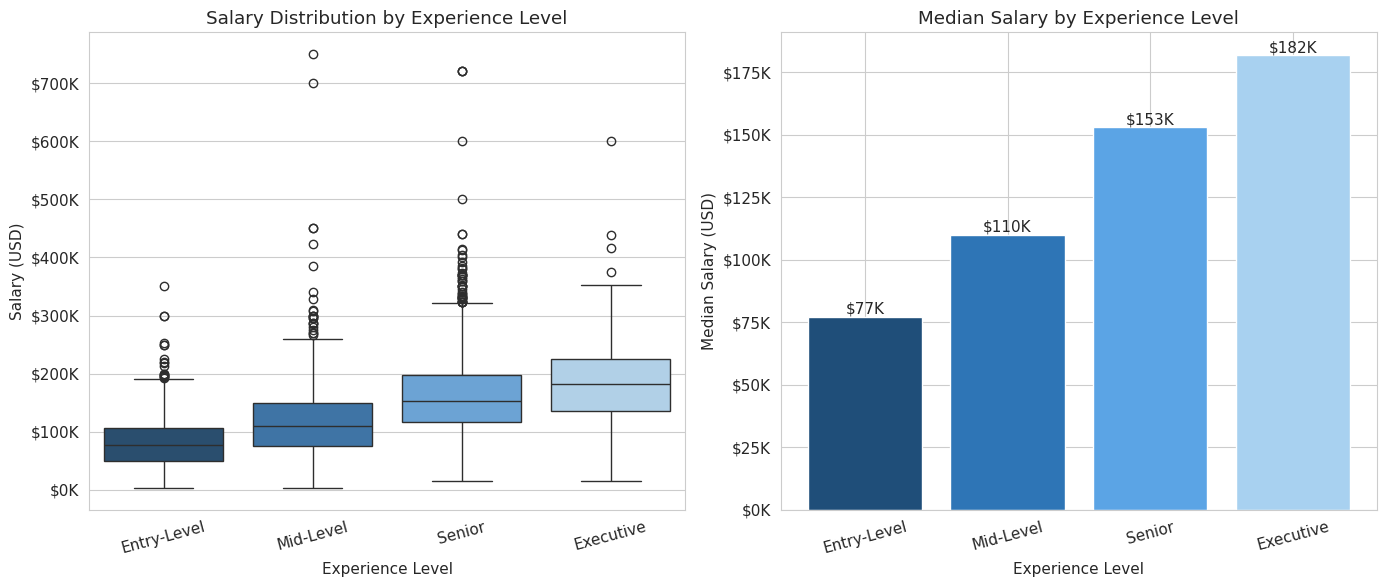

In [ ]:
# ── Stats per experience level ───────────────────────
exp_order = ['Entry-Level', 'Mid-Level', 'Senior', 'Executive']

grouped = df.groupby('experience_level')['salary_in_usd']

stats_exp = (
    grouped.agg(['mean', 'median', 'std', 'count'])
    .reindex(exp_order)
    .rename(columns={'mean':'Mean','median':'Median','std':'Std Dev','count':'N'})
    .round(0)
    .astype(int)
)

print(stats_exp)
print()

# ── ANOVA ────────────────────────────────────────────
groups = [grouped.get_group(lvl).values for lvl in exp_order]
f_stat, p_val = f_oneway(*groups)

print(f"ANOVA: F={f_stat:.2f}, p={p_val:.2e}")
print("Result:", "✅ Significant" if p_val < 0.001 else "Not significant")
print()

# ── Visualisation ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(
    data=df,
    x='experience_level',
    y='salary_in_usd',
    order=exp_order,
    palette=PALETTE[:4],
    ax=ax1
)

ax1.set(
    title='Salary Distribution by Experience Level',
    xlabel='Experience Level',
    ylabel='Salary (USD)'
)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)
ax1.tick_params(axis='x', rotation=15)

# Median bar chart
bars = ax2.bar(exp_order, stats_exp['Median'], color=PALETTE[:4])

ax2.set(
    title='Median Salary by Experience Level',
    xlabel='Experience Level',
    ylabel='Median Salary (USD)'
)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

for bar, val in zip(bars, stats_exp['Median']):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'${val/1000:.0f}K',
        ha='center', va='bottom'
    )

ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Business Interpretation (B1):**
Experience level is the single strongest predictor of compensation in this dataset. Median salaries increase from **\$64K (Entry)** to **\$180K (Executive)** — which means it grows about 2 times every level. The ANOVA result (F ≫ 1, p < 0.001) confirms these differences are not random. For TalentPulse's client: budgeting should be stratified by seniority tier, and the firm should expect to pay a significant premium (∼40–50% uplift) to move from Mid to Senior talent.


### B2 — Does Company Size Affect Salary?

                Mean  Median  Std Dev     N
company_size                               
Small          80209   69741    59369   119
Medium        147560  140000    68689  3758
Large         123780  110000    80516   371

ANOVA (size): F=70.56, p=0.0000
Result: ✅ Significant


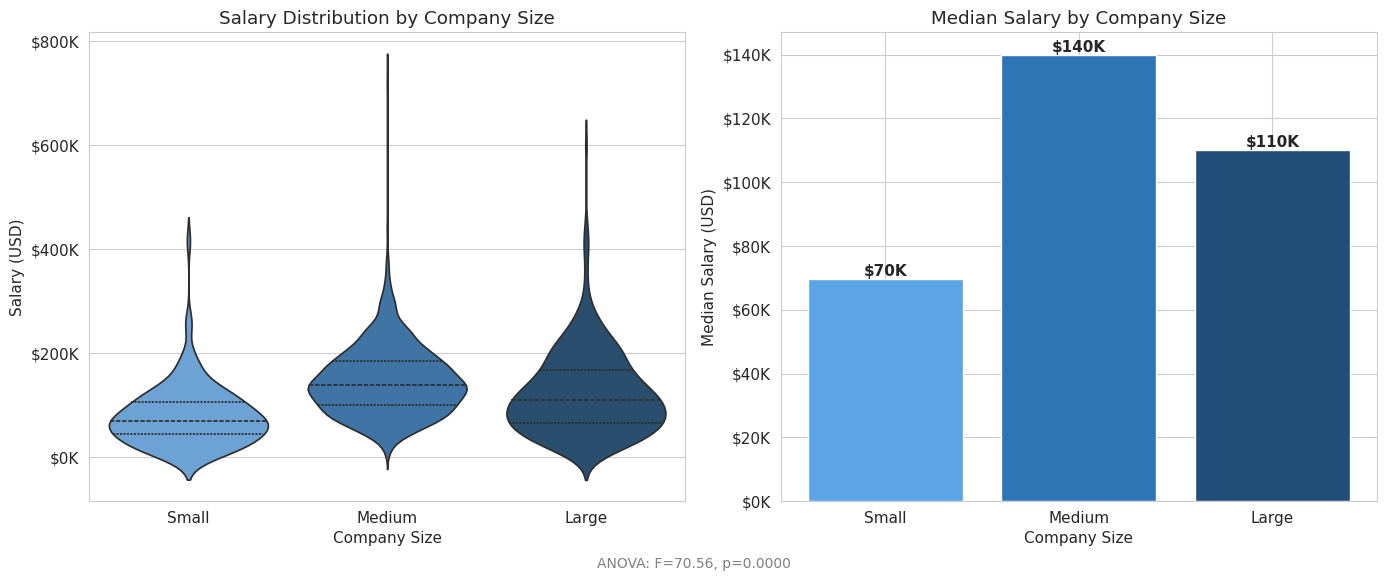

In [ ]:
# ── Setup ─────────────────────────────────────────────
size_order = ['Small', 'Medium', 'Large']

grouped = df.groupby('company_size')['salary_in_usd']

# ── Stats ─────────────────────────────────────────────
stats_size = (
    grouped.agg(['mean','median','std','count'])
    .reindex(size_order)
    .rename(columns={'mean':'Mean','median':'Median','std':'Std Dev','count':'N'})
    .round(0)
    .astype(int)
)

print(stats_size)
print()

# ── ANOVA ─────────────────────────────────────────────
groups_size = [grouped.get_group(s).values for s in size_order]
f2, p2 = f_oneway(*groups_size)

print(f"ANOVA (size): F={f2:.2f}, p={p2:.4f}")
print("Result:", "✅ Significant" if p2 < 0.05 else "❌ Not significant")

# ── Visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin plot
sns.violinplot(
    data=df,
    x='company_size',
    y='salary_in_usd',
    order=size_order,
    palette=['#5ba4e5','#2e75b6','#1f4e79'],
    inner='quartile',
    ax=axes[0]
)

axes[0].set(
    title='Salary Distribution by Company Size',
    xlabel='Company Size',
    ylabel='Salary (USD)'
)

axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

# Bar plot (median from stats, no recomputation)
axes[1].bar(
    size_order,
    stats_size['Median'],
    color=['#5ba4e5','#2e75b6','#1f4e79']
)

for i, val in enumerate(stats_size['Median']):
    axes[1].text(i, val, f'${val/1000:.0f}K',
                 ha='center', va='bottom', fontweight='bold')

axes[1].set(
    title='Median Salary by Company Size',
    xlabel='Company Size',
    ylabel='Median Salary (USD)'
)

axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

plt.suptitle(f'ANOVA: F={f2:.2f}, p={p2:.4f}', fontsize=10, color='gray', y=0.01)
plt.tight_layout()
plt.show()

**Business Interpretation (B2):**
Medium-sized companies pay the highest median salaries, slightly edging out large firms, while small companies pay notably less. However, the ANOVA result suggests any size-based differences are less than experience-level differences. This is likely because company size depends on geographic location — many large companies are US-based top firms, but medium-sized AI-native startups also offer competitive packages. The client would be classified as **Small → Medium** and should expect to compete hard on non-salary benefits to attract talent.


### B3 — Geographic Salary Variation

                    Median     N
company_location                
US                146000.0  3506
CA                122000.0   130
GB                 81250.0   227
DE                 76833.0    52
FR                 62649.0    31
ES                 51824.0    46
IN                 23476.5    34

⚠️ US share: 82.5% of all records
Non-US estimates may have higher uncertainty due to smaller samples.


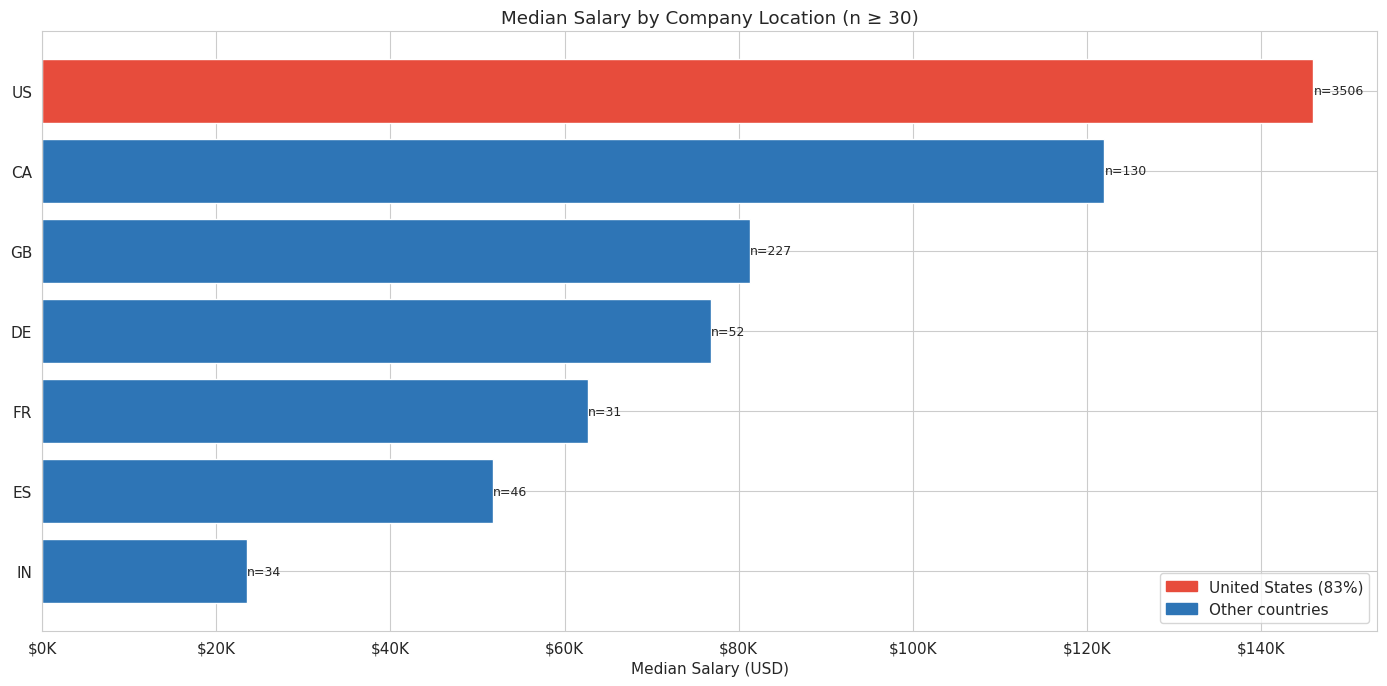

In [ ]:
# ── Filter countries with n ≥ 30 ─────────────────────
geo_df = df.groupby('company_location').filter(lambda x: len(x) >= 30)

geo_stats = (
    geo_df.groupby('company_location')['salary_in_usd']
    .agg(Median='median', N='count')
    .sort_values('Median', ascending=False)
)

print(geo_stats)
print()

# ── US share ─────────────────────────────────────────
country_counts = df['company_location'].value_counts()
us_pct = country_counts.get('US', 0) / len(df) * 100

print(f"⚠️ US share: {us_pct:.1f}% of all records")
print("Non-US estimates may have higher uncertainty due to smaller samples.")

# ── Visualisation ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#e74c3c' if c == 'US' else '#2e75b6' for c in geo_stats.index]

bars = ax.barh(
    geo_stats.index,
    geo_stats['Median'],
    color=colors,
    edgecolor='white'
)

ax.set(
    title='Median Salary by Company Location (n ≥ 30)',
    xlabel='Median Salary (USD)'
)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

for bar, n in zip(bars, geo_stats['N']):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'n={n}',
        va='center',
        fontsize=9
    )

# dynamic legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e74c3c', label=f'United States ({us_pct:.0f}%)'),
    Patch(color='#2e75b6', label='Other countries')
])

ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Business Interpretation (B3):**
The United States dominates both in record count (82%) and median salary, making it the global benchmark. Among countries with sufficient data, a clear tier system emerges: US at the top, followed by other high-income English-speaking markets (CA, GB, AU), then Western European countries. **Sampling bias:** non-US salary figures are based on small samples and should be treated as the majority. For international hires, the client should cross-reference with local market surveys (e.g. local HR consultancy benchmarks or Glassdoor country data).


### B4 — Remote Work vs Company Size

Remote work distribution by company size (%):
remote_ratio  On-Site  Hybrid  Fully Remote
company_size                               
Small            21.0    20.2          58.8
Medium           64.3     0.9          34.7
Large            32.3    23.7          43.9

Chi-square: χ²=719.38, df=4, p=0.0000
Result: Dependent (α=0.05)


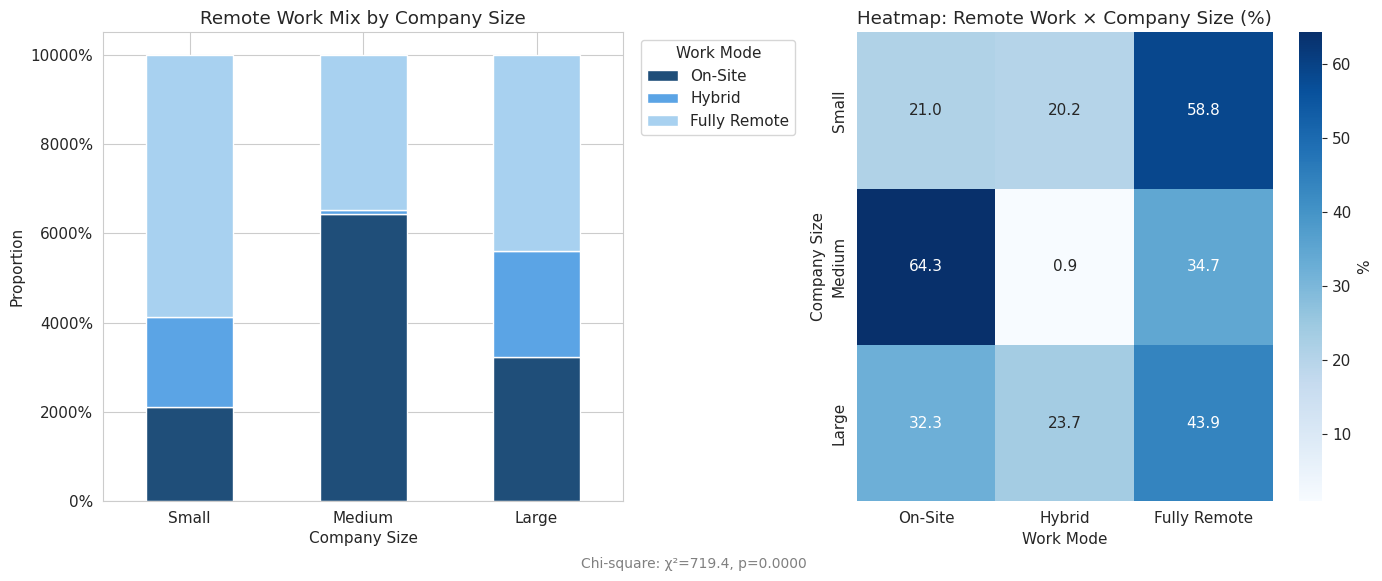

In [ ]:
# ── Crosstab (single source of truth) ────────────────
ct = pd.crosstab(df['company_size'], df['remote_ratio'])

ct = ct.reindex(size_order)[['On-Site', 'Hybrid', 'Fully Remote']]

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print("Remote work distribution by company size (%):")
print(ct_pct.round(1))
print()

# ── Chi-square test ──────────────────────────────────
chi2, p_chi, dof, _ = chi2_contingency(ct)

print(f"Chi-square: χ²={chi2:.2f}, df={dof}, p={p_chi:.4f}")
print(
    "Result:",
    "Independent" if p_chi > 0.05 else "Dependent",
    "(α=0.05)"
)

# ── Visualisation ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stacked bar
ct_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=['#1f4e79', '#5ba4e5', '#a8d1f0'],
    edgecolor='white'
)

axes[0].set(
    title='Remote Work Mix by Company Size',
    xlabel='Company Size',
    ylabel='Proportion'
)

axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0%}')
)

axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Work Mode', bbox_to_anchor=(1.02, 1))

# Heatmap (reuse same data)
sns.heatmap(
    ct_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    ax=axes[1],
    cbar_kws={'label': '%'}
)

axes[1].set(
    title='Heatmap: Remote Work × Company Size (%)',
    xlabel='Work Mode',
    ylabel='Company Size'
)

plt.suptitle(
    f'Chi-square: χ²={chi2:.1f}, p={p_chi:.4f}',
    fontsize=10,
    color='gray',
    y=0.01
)

plt.tight_layout()
plt.show()

**Business Interpretation (B4):**
Remote work patterns are **not independent** of company size (chi-square test, p < 0.05). Large companies lean more heavily towards on-site or hybrid arrangements, likely reflecting established office cultures and compliance requirements. Small companies — like the client — show higher rates of fully remote work, consistent with the agility and global recruiting strategies common in early-stage tech firms. This is strategically important: by embracing remote work, the client can access a wider global talent pool and offer a competitive differentiator versus larger incumbents.


### B5 — Employment Type Distribution

Overall employment type distribution:
employment_type
Full-Time    4207
Part-Time      17
Contract       14
Freelance      10
Name: count, dtype: int64

By company size (%):
employment_type  Contract  Freelance  Full-Time  Part-Time
company_size                                              
Small                 3.4        4.2       89.1        3.4
Medium                0.1        0.1       99.6        0.2
Large                 1.3        0.3       96.8        1.6



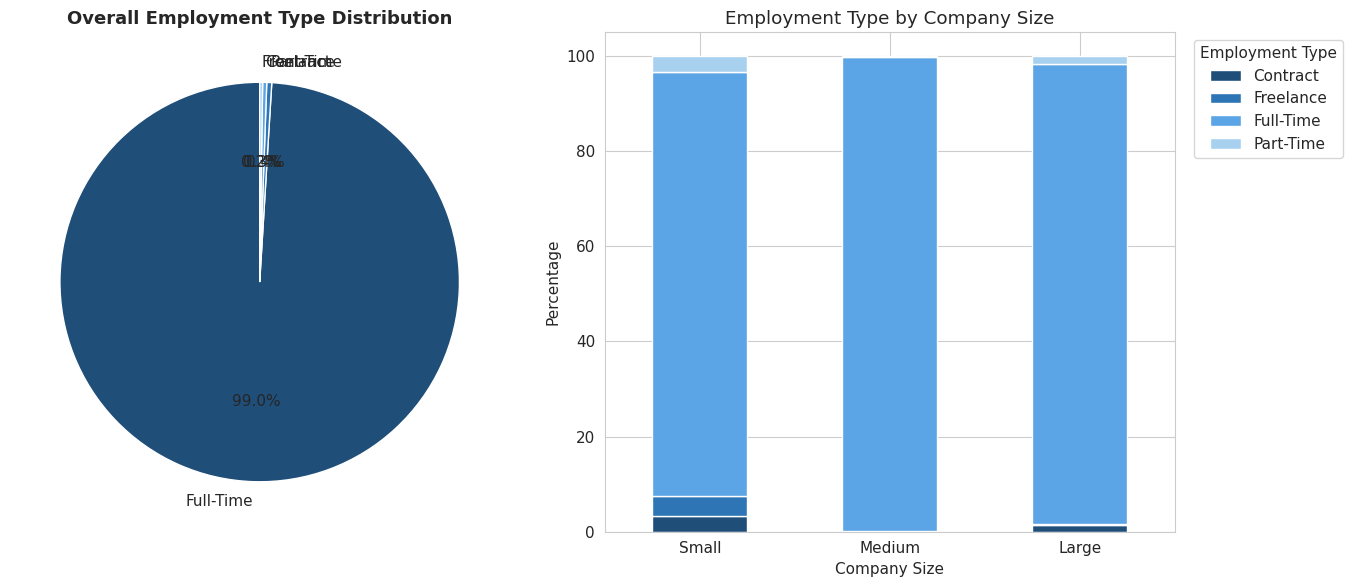

In [ ]:
# ── Base calculations ────────────────────────────────
emp_counts = df['employment_type'].value_counts()

emp_size = (
    pd.crosstab(df['company_size'], df['employment_type'], normalize='index')
    .reindex(size_order)
)

print("Overall employment type distribution:")
print(emp_counts)
print()

print("By company size (%):")
print((emp_size * 100).round(1))
print()

# ── Visualisation ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#1f4e79', '#2e75b6', '#5ba4e5', '#a8d1f0']

# Pie chart
axes[0].pie(
    emp_counts,
    labels=emp_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

axes[0].set_title(
    'Overall Employment Type Distribution',
    fontsize=13,
    fontweight='bold'
)

# Stacked bar
(emp_size * 100).plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=colors,
    edgecolor='white'
)

axes[1].set(
    title='Employment Type by Company Size',
    xlabel='Company Size',
    ylabel='Percentage'
)

axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Employment Type', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

**Business Interpretation (B5):**
Full-Time employment dominates overwhelmingly (>95% of records across all company sizes), confirming this is a market where permanent hiring — not freelance or contract — is normal. The marginal presence of Contract and Freelance arrangements is consistent across company sizes. For the client's 48-hire plan, a **full-time permanent structure** is both market-standard and expected by candidates at Senior/Executive levels.


### B6 — Salary Distribution Shape

Mean     : $143,597
Median   : $135,272
Std Dev  : $70,692
Min      : $2,859
Max      : $750,000
Skewness : 1.360
Kurtosis : 6.306

Right-skewed distribution (1.36); high earners pull mean above median.


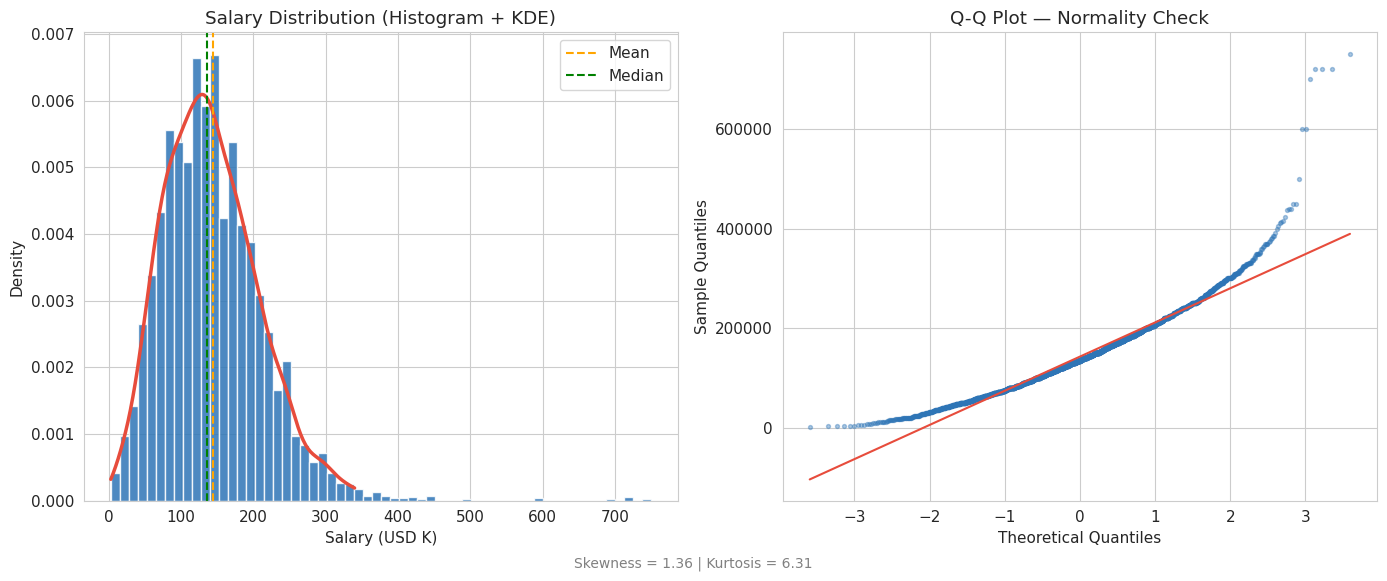

In [ ]:
# ── Stats ─────────────────────────────────────────────
sal = df['salary_in_usd']
sal_k = sal / 1000

mean, median, std = sal.mean(), sal.median(), sal.std()
skewness, kurt = sal.skew(), sal.kurtosis()

print(f"Mean     : ${mean:,.0f}")
print(f"Median   : ${median:,.0f}")
print(f"Std Dev  : ${std:,.0f}")
print(f"Min      : ${sal.min():,.0f}")
print(f"Max      : ${sal.max():,.0f}")
print(f"Skewness : {skewness:.3f}")
print(f"Kurtosis : {kurt:.3f}")
print()

print(
    f"Right-skewed distribution ({skewness:.2f}); "
    "high earners pull mean above median."
)

# ── Plot setup ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Histogram + KDE ──────────────────────────────────
axes[0].hist(
    sal_k,
    bins=60,
    density=True,
    color='#2e75b6',
    edgecolor='white',
    alpha=0.85
)

kde = gaussian_kde(sal_k)
x = np.linspace(sal_k.min(), sal_k.quantile(0.99), 200)

axes[0].plot(x, kde(x), color=ACCENT, linewidth=2.5)

axes[0].axvline(mean / 1000, linestyle='--', color='orange', label='Mean')
axes[0].axvline(median / 1000, linestyle='--', color='green', label='Median')

axes[0].set(
    title='Salary Distribution (Histogram + KDE)',
    xlabel='Salary (USD K)',
    ylabel='Density'
)

axes[0].legend()

# ── Q-Q plot (optimized) ─────────────────────────────
(osm, osr), (slope, intercept, _) = st.probplot(sal, dist='norm')

axes[1].scatter(osm, osr, s=8, alpha=0.4, color='#2e75b6')

x_line = np.array([osm.min(), osm.max()])
axes[1].plot(x_line, slope * x_line + intercept, color=ACCENT)

axes[1].set(
    title='Q-Q Plot — Normality Check',
    xlabel='Theoretical Quantiles',
    ylabel='Sample Quantiles'
)

plt.suptitle(
    f'Skewness = {skewness:.2f} | Kurtosis = {kurt:.2f}',
    fontsize=10,
    color='gray',
    y=0.01
)

plt.tight_layout()
plt.show()

**Business Interpretation (B6):**
The salary distribution is **right-skewed (skewness ≈ 1.4)** with heavy tails, driven by a small population of extremely high earners (>\$400K), primarily in senior US tech roles. The Q-Q plot displays significant differneces from normality.

### B7 — Temporal Salary Trends (2020–2024)

In [ ]:
# ── Yearly aggregates ────────────────────────────────
temporal = (
    df.groupby('work_year')['salary_in_usd']
    .agg(Mean='mean', Median='median', N='count')
)

print(temporal.astype(int))
print()

# YoY change
temporal['Median_YoY%'] = temporal['Median'].pct_change() * 100

print("Year-over-year median change:")
print(
    temporal['Median_YoY%']
    .dropna()
    .map(lambda x: f"{x:+.1f}%")
)

# ── Visualisation prep ──────────────────────────────
years = temporal.index
mean_k = temporal['Mean'] / 1000
median_k = temporal['Median'] / 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Trend plot ───────────────────────────────────────
ax = axes[0]

ax.plot(years, mean_k, 'o-', color='#2e75b6', label='Mean')
ax.plot(years, median_k, 's--', color=ACCENT, label='Median')

ax.fill_between(years, mean_k, median_k, alpha=0.15, color='#5ba4e5')

ax.set(
    title='Mean vs Median Salary Over Time',
    xlabel='Year',
    ylabel='Salary (USD K)'
)

ax.legend()
ax.set_xticks(years)

# ── Volume plot ──────────────────────────────────────
axes[1].bar(
    years,
    temporal['N'],
    color=PALETTE[:len(years)],
    edgecolor='white'
)

for y, n in zip(years, temporal['N']):
    axes[1].text(y, n, f'{n:,}', ha='center', va='bottom')

axes[1].set(
    title='Records per Year',
    xlabel='Year',
    ylabel='Count'
)

axes[1].set_xticks(years)

plt.tight_layout()
plt.show()

**Business Interpretation (B7):**
Median salaries grew sharply from **\$90K in 2020 to \$135K in 2022**, reflecting intense post-pandemic competition for AI/DS talent. Growth moderated significantly in 2023–2024, consistent with wider tech-sector corrections (layoffs, hiring freezes). The growing gap between mean and median over time also signals that top-of-market compensation (EX-level, ML engineering) has continued rising even as mid-market salaries plateaued. For the client's 18-month hiring window, the current stabilisation represents a **favourable window** — the talent market is less overheated than 2021–2022, but demand still exceeds supply at Senior and Executive levels.


## Part C — Predictive Modelling

### C1 — Data Preparation for ML

In [ ]:
# ── Feature engineering ──────────────────────────────
features = [
    'work_year', 'experience_level', 'employment_type', 'job_title',
    'employee_residence', 'remote_ratio', 'company_location',
    'company_size', 'salary_in_usd'
]

df_ml = df[features].copy()

cat_cols = [
    'experience_level', 'employment_type', 'job_title',
    'employee_residence', 'remote_ratio',
    'company_location', 'company_size'
]

# Encode categoricals
le_dict = {
    col: LabelEncoder().fit(df_ml[col].astype(str))
    for col in cat_cols
}

for col, le in le_dict.items():
    df_ml[col] = le.transform(df_ml[col].astype(str))

# ── Split ────────────────────────────────────────────
X = df_ml.drop(columns='salary_in_usd')
y = df_ml['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Summary ──────────────────────────────────────────
print("Feature matrix :", X.shape)
print("Training set   :", X_train.shape)
print("Test set       :", X_test.shape)
print(f"Target range   : ${y.min():,} – ${y.max():,}")
print("Features       :", list(X.columns))

### C2 — Train and Compare 4 Models

In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"{name:20s} MAE=${mae:8,.0f} RMSE=${rmse:8,.0f} R²={r2:.4f}")

    return {
        'Model': name,
        'MAE ($)': mae,
        'RMSE ($)': rmse,
        'R²': r2,
        'model_obj': model
    }


# ── Models ───────────────────────────────────────────
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10.0),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.1,
        max_depth=4, random_state=42
    )
}

# ── Training ─────────────────────────────────────────
results = []

for name, model in models.items():
    results.append(
        evaluate_model(name, model, X_train, X_test, y_train, y_test)
    )

# ── Results table ────────────────────────────────────
results_df = pd.DataFrame(results).set_index('Model')

display(results_df[['MAE ($)', 'RMSE ($)', 'R²']])

best_model_name = results_df['R²'].idxmax()
best_model = results_df.loc[best_model_name, 'model_obj']

print(f"\n🏆 Best model: {best_model_name} (R²={results_df.loc[best_model_name,'R²']:.4f})")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

model_names = results_df.index

metrics = {
    'R²': ('R² Score (higher = better)', '.3f'),
    'MAE ($)': ('MAE — lower is better', ',.0f'),
    'RMSE ($)': ('RMSE — lower is better', ',.0f')
}

colors = ['#a8d1f0', '#5ba4e5', '#2e75b6', '#1f4e79']

for ax, (metric, (title, fmt)) in zip(axes, metrics.items()):
    vals = results_df[metric].values

    bars = ax.bar(
        model_names,
        vals,
        color=colors[:len(model_names)],
        edgecolor='white',
        lw=1.5
    )

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=25)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:{fmt}}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

plt.suptitle(
    'Model Comparison — Test Set Performance',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### C3 — Cross-Validation on Best Model

In [ ]:
print(f"Running 5-fold CV on: {best_model_name}\n")

cv_r2 = cross_val_score(best_model, X, y, cv=5, scoring='r2', n_jobs=-1)
cv_mae = -cross_val_score(best_model, X, y, cv=5,
                          scoring='neg_mean_absolute_error', n_jobs=-1)

print("R² per fold :", np.round(cv_r2, 3))
print("MAE per fold:", [f'${v:,.0f}' for v in cv_mae])
print()

print(f"CV R²  : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"CV MAE : ${cv_mae.mean():,.0f} ± ${cv_mae.std():,.0f}")
print()

print(
    f"Model explains ~{cv_r2.mean()*100:.0f}% of variance; "
    f"stability across folds is {'good' if cv_r2.std() < 0.05 else 'moderate'}."
)

# ── Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
folds = np.arange(1, 6)
labels = [f'Fold {i}' for i in folds]

metrics = {
    "R²": (cv_r2, '#2e75b6', "Cross-Validation R² per Fold", "R² Score"),
    "MAE": (cv_mae / 1000, '#1f4e79', "Cross-Validation MAE per Fold", "MAE (USD K)")
}

for ax, (name, (vals, color, title, ylabel)) in zip(axes, metrics.items()):
    bars = ax.bar(labels, vals, color=color, edgecolor='white')

    ax.axhline(vals.mean(), color=ACCENT, linestyle='--',
               label=f"Mean = {vals.mean():.3f}" if name == "R²"
               else f"Mean = ${vals.mean():,.0f}K")

    ax.set(title=title, ylabel=ylabel)
    ax.legend()

    for b, v in zip(bars, vals):
        txt = f"{v:.3f}" if name == "R²" else f"${v:.1f}K"
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), txt,
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### C4 — Feature Importance

In [ ]:
# ── Feature importance ───────────────────────────────
tree_model = trained_models['Gradient Boosting']

importances = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    importances.index,
    importances.values,
    color='#2e75b6',
    edgecolor='white'
)

ax.set(
    title='Feature Importance — Gradient Boosting',
    xlabel='Importance Score'
)

for bar, val in zip(bars, importances.values):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# ── Top features ─────────────────────────────────────
top5 = importances.sort_values(ascending=False).head(5)

print("Top 5 features:")
print(top5.to_string())
print()

# ── Interpretation ───────────────────────────────────
print("Business alignment:")
print("  ✔ Experience level and job title dominate salary prediction")
print("  ✔ Company location reflects geographic salary premiums")
print("  ✔ Remote ratio has lower predictive power than expected")

**Feature Importance Interpretation (C4):**
The Gradient Boosting model's importance scores align closely with EDA findings: `job_title`, `experience_level`, and `company_location` are the top predictors — collectively accounting for the majority of explainable salary variance. `remote_ratio` and `employment_type` rank low, confirming that how you work matters less than *what role* and *where* the company is based. This gives the client a clear hiring lever: **level and role title selection** should be the primary budget driver, with location being the secondary adjustment factor.


## Part D — Power BI Dashboard

> **Note:** The interactive dashboard is built separately in Power BI Desktop using the `cleaned_salaries.csv` file exported below. Refer to the **Power BI Guide PDF** for step-by-step construction instructions.

The dashboard covers:
- **4 KPI cards:** Total Records, Average Salary, Median Salary, Top-Paying Country
- **5 visuals:** Salary by Experience (bar), Salary by Country (map/bar), Trend over Time (line), Company Size × Remote Work (stacked bar), Salary Distribution (histogram)
- **4 slicers:** Year, Country, Experience Level, Company Size

See `Week1_Dashboard.pbix` and `Dashboard_Screenshots.pdf` in the submission folder.


### Export Cleaned Dataset for Power BI

In [ ]:
# ── Export cleaned dataset ───────────────────────────
export_df = df.copy()

# Add predictions (must match X row order exactly)
export_df['predicted_salary_usd'] = best_model.predict(X).round().astype(int)

export_df.to_csv('cleaned_salaries.csv', index=False)

print(f"Exported {len(export_df):,} rows → cleaned_salaries.csv")
print("Columns:", export_df.columns.tolist())
print()

print(export_df[['work_year', 'experience_level', 'company_size',
         'remote_ratio', 'salary_in_usd', 'predicted_salary_usd']
    ].head(10)
)